# Hardware-Aware Quantum Neural Network for Superconductor $T_c$ Prediction

**BasQ Challenge (Challenge 5) — CERN Quantum Materials Hackathon 2026**

Team: Loïc, Haripriya, Abbas, Karla, Khadija, Sam · Mentors: Benjamin Tirado & Unai Aseguinolaza

---

This notebook is the complete, reproducible record of our study: a 4-qubit
data-re-uploading quantum neural network that predicts the superconducting
critical temperature $T_c$ from the UCI superconductivity dataset, designed
*backwards* from the constraints of IBM Heron hardware and evaluated on the
real QPU `ibm_fez`.

**Headline results** (all reproduced live below):

| Result | Value |
|---|---|
| Champion QNN, ideal simulation (200-pt test) | **19.8 K RMSE** — beats linear (20.2) and a parameter-matched MLP (21.3) on the same inputs |
| Noise ladder on the frozen 50 test materials | ideal 23.00 → noisy sim 22.86 → **real QPU 22.89 K** (flat to within shot noise) |
| Mitigation ablation | raw 24.62 → **TREX alone 22.90 K = ideal**; DD / twirling / ZNE add nothing for a 3-CZ circuit |
| Chip tiling (25 parallel copies) | 50 → 2 parameter rows, 12 vs ~41 QPU-s, +0.55 K |
| Seed robustness | QNN **19.84 ± 0.03 K** vs MLP 26.68 ± 4.61 K over 3 seeds |
| Out-of-time validation (post-2018 materials) | QNN **3.93 K RMSE** on 14 clean unseen superconductors |

**How to reproduce.** Run all cells top to bottom (`Kernel → Restart & Run All`).
Everything classical (data prep, baselines, model evaluation, transpilation,
noisy simulation) recomputes live from `data/train.csv` and the shipped trained
weights. Hardware results are recomputed live from the stored QPU expectation
values in `data/` (with job IDs in the appendix); three flags let you regenerate
any stage from scratch:

```
RETRAIN   = False   # True: retrain the champion QNN (sweep budget, ~8 min CPU)
RUN_NOISY = True    # noisy Aer simulation of a Heron backend (~2 min CPU)
RUN_QPU   = False   # True: resubmit the QPU jobs (needs IBM Quantum credentials)
```

**Contents.** 1 Setup · 2 Data & preprocessing · 3 Classical baselines ·
4 The QNN (math + circuit) · 5 Architecture comparison · 6 Transpilation &
the coupling map · 7 The parameter-binding bug (a cautionary tale) ·
8 Noise ladder: simulator → QPU · 9 Mitigation ablation · 10 Chip tiling ·
11 Robustness & out-of-time validation · 12 Additional studies ·
13 Conclusions · 14 Reproducibility appendix


## 1 · Setup

Fixed seeds everywhere: the train/test split, subsampling, weight
initialisation, and simulator seeds are all pinned, so every number in this
notebook is deterministic (QPU runs excepted — those are physical experiments,
and their stored outputs are what we recompute from).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42                      # split + subsample seed (never change)
RETRAIN   = False              # retrain champion QNN from scratch (~8 min)
RUN_NOISY = True               # noisy Aer simulation of Heron (~2 min)
RUN_QPU   = False              # resubmit real QPU jobs (needs credentials)

# validated categorical palette (fixed slot order) + neutral ink
COL = {"blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100",
       "red": "#e34948", "violet": "#4a3aa7", "gray": "#52514e"}

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.25,
    "axes.axisbelow": True, "font.size": 10.5,
})

import qiskit, qiskit_aer, qiskit_machine_learning, sklearn
print("qiskit", qiskit.__version__, "| aer", qiskit_aer.__version__,
      "| qiskit-ml", qiskit_machine_learning.__version__,
      "| sklearn", sklearn.__version__,
      "| numpy", np.__version__, "| pandas", pd.__version__)

qiskit 2.5.0 | aer 0.17.2 | qiskit-ml 0.9.0 | sklearn 1.9.0 | numpy 2.5.1 | pandas 3.0.3


## 2 · Data & preprocessing

The UCI superconductivity dataset: 21,263 rows × 81 features (statistics of 8
elemental properties over each material's composition) with target
`critical_temp` in Kelvin.

**Three preprocessing decisions, each with a reason:**

1. **Deduplication.** The raw file contains repeated measurements of the same
   material (identical feature vectors, different $T_c$). We keep one row per
   unique feature vector with the mean $T_c$ — otherwise near-duplicates leak
   across the train/test split.

2. **Log target.** $T_c$ is heavily right-skewed (most materials < 20 K, a tail
   to 185 K). We regress on

$$y=\ln\!\left(1+T_c\right),$$

   which evens out the distribution (plot below) and means errors are relative
   rather than absolute — appropriate for a quantity spanning two orders of
   magnitude.

3. **Dimensionality reduction to 4 features** — one per qubit. We compare two
   projections, both fitted **on the training split only** (no leakage):

   - **PCA** (unsupervised): directions of maximum feature variance,
     $\max_{\lVert w\rVert=1}\operatorname{Var}(Xw)$ — knows nothing about $T_c$.
   - **PLS** (supervised): directions of maximum covariance **with the target**,
     $\max_{\lVert w\rVert=1}\operatorname{Cov}(Xw,\,y)$ — the full training
     set's information about $T_c$ is absorbed classically, and the quantum
     circuit reads the distilled result.

**Scaling for the quantum circuit.** Features become rotation angles and the
target must live inside the observable's range $[-1,1]$:

$$x_j \mapsto [-\tfrac{\pi}{2}, \tfrac{\pi}{2}], \qquad y \mapsto [-0.8,\, 0.8]$$

(the ±0.8 leaves headroom: $\langle Z\rangle=\pm1$ requires perfectly pure
states, which noise never delivers). Finally we subsample 800 training / 200
test rows for the QNN experiments (statevector training on 21k rows is
pointless — the model comparison needs a *common* subset), keeping the full
splits for classical baselines. Predictions are inverted back to Kelvin via
$\hat T_c = e^{\hat y}-1$ before any metric is reported.

In [2]:
df_raw = pd.read_csv("data/train.csv")
feat_cols = [c for c in df_raw.columns if c != "critical_temp"]
df = df_raw.groupby(feat_cols, as_index=False)["critical_temp"].mean()
print(f"raw rows {len(df_raw)}  ->  deduplicated {len(df)} unique materials")
print(f"Tc range {df.critical_temp.min():.2f} .. {df.critical_temp.max():.1f} K, "
      f"median {df.critical_temp.median():.1f} K")

raw rows 21263  ->  deduplicated 15170 unique materials
Tc range 0.00 .. 143.0 K, median 19.1 K


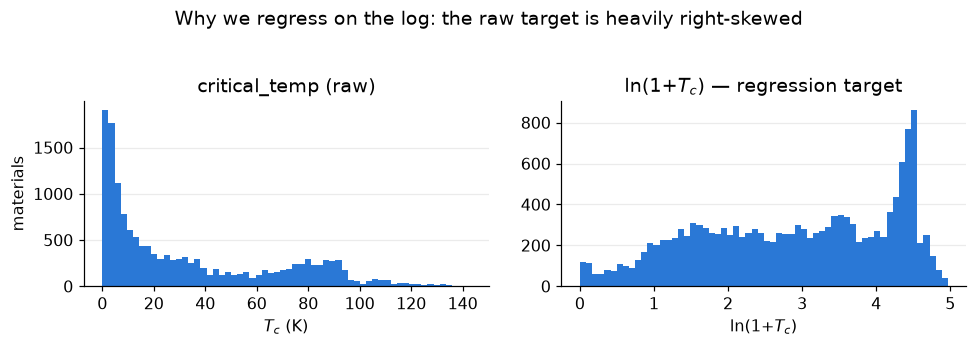

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(df.critical_temp, bins=60, color=COL["blue"])
axes[0].set(title="critical_temp (raw)", xlabel="$T_c$ (K)", ylabel="materials")
axes[1].hist(np.log1p(df.critical_temp), bins=60, color=COL["blue"])
axes[1].set(title="ln(1+$T_c$) — regression target", xlabel="ln(1+$T_c$)")
fig.suptitle("Why we regress on the log: the raw target is heavily right-skewed",
             y=1.04)
plt.tight_layout(); plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression


def prepare(n_features=4, n_train=800, n_test=200, seed=SEED, reduction="pca"):
    """Dedupe -> log target -> split -> (train-fitted) reduce + scale -> subsample.
    Identical to the pipeline's prep_data.prepare (same seeds, same order)."""
    X = df.drop(columns="critical_temp").values
    y = np.log1p(df["critical_temp"].values)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                              random_state=seed)
    std = StandardScaler().fit(X_tr)                       # train only!
    if reduction == "pls":
        red = PLSRegression(n_components=n_features).fit(std.transform(X_tr), y_tr)
    else:
        red = PCA(n_components=n_features, random_state=seed).fit(std.transform(X_tr))
    Z_tr, Z_te = red.transform(std.transform(X_tr)), red.transform(std.transform(X_te))

    xs = MinMaxScaler((-np.pi / 2, np.pi / 2)).fit(Z_tr)   # angles
    ys = MinMaxScaler((-0.8, 0.8)).fit(y_tr.reshape(-1, 1))  # observable range

    rng = np.random.default_rng(seed)
    i_tr = rng.choice(len(Z_tr), size=n_train, replace=False)
    i_te = rng.choice(len(Z_te), size=n_test, replace=False)
    return dict(
        X_train=xs.transform(Z_tr)[i_tr],
        y_train=ys.transform(y_tr.reshape(-1, 1)).ravel()[i_tr],
        X_test=xs.transform(Z_te)[i_te],
        y_test=ys.transform(y_te.reshape(-1, 1)).ravel()[i_te],
        X_train_full=xs.transform(Z_tr), y_train_full=ys.transform(y_tr.reshape(-1, 1)).ravel(),
        X_test_full=xs.transform(Z_te), y_test_full=ys.transform(y_te.reshape(-1, 1)).ravel(),
        y_min=ys.data_min_[0], y_max=ys.data_max_[0])


def inverse_target(ys_scaled, y_min, y_max):
    """Scaled prediction -> Kelvin."""
    y = (ys_scaled + 0.8) / 1.6 * (y_max - y_min) + y_min
    return np.expm1(y)


def rmse_kelvin(y_true_s, y_pred_s, d):
    yt = inverse_target(np.asarray(y_true_s), d["y_min"], d["y_max"])
    yp = inverse_target(np.clip(np.asarray(y_pred_s), -1, 1), d["y_min"], d["y_max"])
    err = yt - yp
    return float(np.sqrt(np.mean(err ** 2))), float(np.mean(np.abs(err)))


d_pca = prepare(reduction="pca")
d_pls = prepare(reduction="pls")

# reproducibility check against the artifacts shipped with this notebook
for name, d in [("prepared_4d.npz", d_pca), ("prepared_4d_pls.npz", d_pls)]:
    ref = dict(np.load(f"data/{name}"))
    ok = all(np.allclose(d[k], ref[k]) for k in ("X_train", "y_train", "X_test", "y_test"))
    print(f"{name}: regenerated == shipped artifact -> {ok}")
print(f"shapes: train {d_pls['X_train'].shape}, test {d_pls['X_test'].shape}; "
      f"the 'frozen 50' = X_test[:50], identical materials in both pipelines")

prepared_4d.npz: regenerated == shipped artifact -> True
prepared_4d_pls.npz: regenerated == shipped artifact -> True
shapes: train (800, 4), test (200, 4); the 'frozen 50' = X_test[:50], identical materials in both pipelines


## 3 · Classical baselines

The challenge asks for a comparison against a classical model *with a similar
number of trainable parameters*. Our champion QNN has **32** parameters, so the
fair rival is an MLP with one hidden layer of width $h$, giving $(k+2)h+1 = 31$
parameters at $h=5,\ k=4$. We also report unconstrained classical models
honestly — they define what the QNN is *not* claiming to beat:

- **Linear regression** on the same 4 inputs — the "is a QNN even useful?" floor;
- **Random forest** on the same 4 inputs — unconstrained capacity, same information;
- **HistGradientBoosting on all reduced-space rows** — the information ceiling
  of the 4-feature representation itself.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor


def run_baselines(d, label):
    out = {}
    models = {
        "linear": LinearRegression(),
        "MLP h=5 (31 params)": MLPRegressor(hidden_layer_sizes=(5,),
                                            max_iter=4000, random_state=0),
        "random forest": RandomForestRegressor(n_estimators=200, random_state=0),
    }
    for name, m in models.items():
        m.fit(d["X_train"], d["y_train"])
        out[name] = rmse_kelvin(d["y_test"], m.predict(d["X_test"]), d)[0]
    gbm = HistGradientBoostingRegressor(random_state=0)
    gbm.fit(d["X_train_full"], d["y_train_full"])
    out["HistGBM (all rows)"] = rmse_kelvin(
        d["y_test_full"], gbm.predict(d["X_test_full"]), d)[0]
    print(f"--- {label}")
    for k, v in out.items():
        print(f"  {k:24s} {v:6.2f} K")
    return out


base_pca = run_baselines(d_pca, "PCA-4 inputs")
base_pls = run_baselines(d_pls, "PLS-4 inputs")

--- PCA-4 inputs
  linear                    22.43 K
  MLP h=5 (31 params)       25.23 K
  random forest             18.47 K
  HistGBM (all rows)        17.02 K


--- PLS-4 inputs
  linear                    20.15 K
  MLP h=5 (31 params)       21.32 K
  random forest             18.48 K
  HistGBM (all rows)        15.88 K


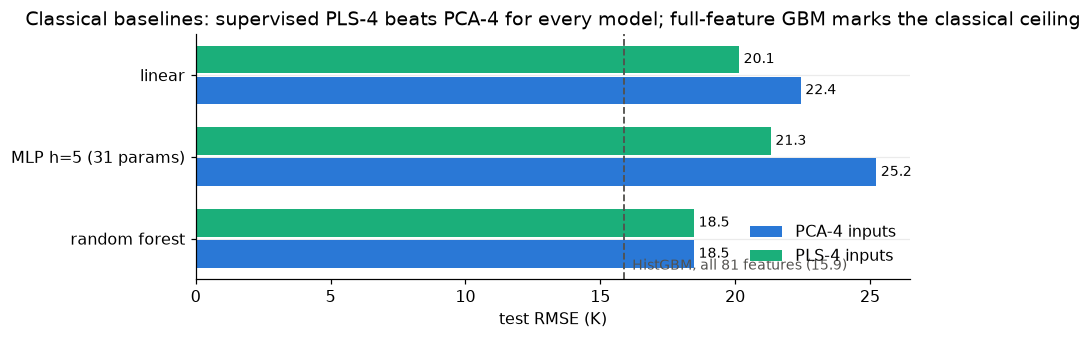

In [6]:
names = ["linear", "MLP h=5 (31 params)", "random forest"]
ypos = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8.5, 3.2))
b1 = ax.barh(ypos + 0.19, [base_pca[n] for n in names], 0.34,
             color=COL["blue"], label="PCA-4 inputs")
b2 = ax.barh(ypos - 0.19, [base_pls[n] for n in names], 0.34,
             color=COL["aqua"], label="PLS-4 inputs")
ax.bar_label(b1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.1f", padding=3, fontsize=9)
ax.axvline(base_pls["HistGBM (all rows)"], color=COL["gray"], ls="--", lw=1.2)
ax.text(base_pls["HistGBM (all rows)"] + 0.3, 2.38,
        f"HistGBM, all 81 features ({base_pls['HistGBM (all rows)']:.1f})",
        color=COL["gray"], fontsize=9)
ax.set(yticks=ypos, yticklabels=names, xlabel="test RMSE (K)",
       title="Classical baselines: supervised PLS-4 beats PCA-4 for every model;"
             " full-feature GBM marks the classical ceiling")
ax.invert_yaxis()
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 4 · The quantum neural network

### The model as a function

The QNN is a parametrised function $f(\mathbf{x},\boldsymbol\theta)$ from 4
input features to one number, implemented as a quantum circuit on $n=4$ qubits
with $L$ layers. Each layer $\ell$ applies three sublayers:

$$
|\psi(\mathbf{x},\boldsymbol\theta)\rangle \;=\;
\left[\prod_{\ell=1}^{L} U_{\text{ent}}\; U_{\text{var}}(\boldsymbol a_\ell,\boldsymbol c_\ell)\;
U_{\text{enc}}(\mathbf{x};\boldsymbol s_\ell,\boldsymbol o_\ell)\right] |0\rangle^{\otimes 4}
$$

- **Encoding** (data re-uploading, *trainable frequencies*):
  $U_{\text{enc}}=\bigotimes_{q} R_y\!\big(s_{\ell q}\, x_{f(q,\ell)} + o_{\ell q}\big)$,
  where $f(q,\ell)=(q+\ell)\bmod 4$ assigns features to qubits round-robin, and
  scale $s$ / offset $o$ are **trainable**.
- **Variational**: $U_{\text{var}}=\bigotimes_q R_y(c_{\ell q})R_z(a_{\ell q})$ —
  two rotation axes suffice to reach any single-qubit state; $R_z$ is chosen
  because it is *free* on IBM hardware (a virtual frame rotation).
- **Entanglement**: $U_{\text{ent}}=\prod_{q=0}^{2}\mathrm{CZ}_{q,q+1}$, a linear
  chain matching the heavy-hex coupling map — **and skipped after the last
  layer**, because CZ is diagonal in the measurement basis: placed right before
  measurement it cannot change any statistics, only add noise.

The prediction is the average single-qubit $Z$ expectation:

$$
f(\mathbf{x},\boldsymbol\theta)=\Big\langle \psi \Big|\; \tfrac{1}{4}\textstyle\sum_{q=0}^{3} Z_q \;\Big|\psi\Big\rangle \in [-1,1].
$$

A *local* observable like this avoids barren plateaus and is friendly to
readout noise (single-qubit readout errors partially average out).

### Why this is a learning machine: the Fourier picture

Because each feature enters only through $R_y(s\,x+o)$, the output is exactly a
truncated Fourier series in the inputs,

$$
f(\mathbf{x},\boldsymbol\theta)=\sum_{\boldsymbol\omega\in\Omega} c_{\boldsymbol\omega}(\boldsymbol\theta)\, e^{i\,\boldsymbol\omega\cdot\mathbf{x}},
$$

where re-uploading the data in every layer enlarges the frequency set $\Omega$,
and — because our scales $s_{\ell q}$ are trainable — the model **learns its own
frequencies** rather than being stuck with integer multiples (Pérez-Salinas
2020; Schuld 2021).

### Training

Mean-squared-error loss, minimised by L-BFGS-B; gradients come from the
**parameter-shift rule**,

$$
\frac{\partial f}{\partial \theta_j} = \tfrac12\Big[f\big(\theta_j+\tfrac{\pi}{2}\big) - f\big(\theta_j-\tfrac{\pi}{2}\big)\Big],
$$

which costs **2 circuit evaluations per parameter per sample per step** — the
reason training happens in exact simulation and only *inference* runs on the
QPU. Weights are initialised small, $\theta\sim\mathcal U(-0.3,0.3)$, another
barren-plateau guard.

champion circuit: 4 qubits x 2 layers, 32 trainable parameters, 3 CZ gates


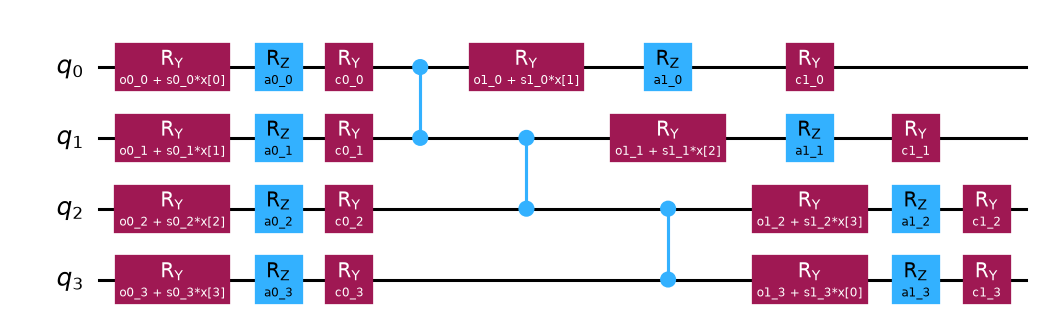

In [7]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN


def build_circuit(n_qubits, n_layers, n_features, entangle=True):
    """The ansatz exactly as described above. Returns (qc, inputs, weights, obs)."""
    x = ParameterVector("x", n_features)
    qc = QuantumCircuit(n_qubits)
    weights = []

    def w(name):
        p = Parameter(name)
        weights.append(p)
        return p

    for layer in range(n_layers):
        for q in range(n_qubits):                      # encoding (re-uploaded)
            f = (q + layer) % n_features
            qc.ry(w(f"s{layer}_{q}") * x[f] + w(f"o{layer}_{q}"), q)
        for q in range(n_qubits):                      # variational
            qc.rz(w(f"a{layer}_{q}"), q)
            qc.ry(w(f"c{layer}_{q}"), q)
        if entangle and n_qubits > 1 and layer < n_layers - 1:
            for q in range(n_qubits - 1):              # CZ chain (not last layer)
                qc.cz(q, q + 1)

    obs = SparsePauliOp.from_sparse_list(
        [("Z", [q], 1 / n_qubits) for q in range(n_qubits)], num_qubits=n_qubits)
    return qc, list(x), weights, obs


def qnn_forward(n_layers, X, weights_vec, n_qubits=4, n_features=4):
    """Exact statevector evaluation of f(x, theta) for a batch of inputs."""
    qc, inputs, wparams, obs = build_circuit(n_qubits, n_layers, n_features)
    qnn = EstimatorQNN(circuit=qc, observables=obs,
                       input_params=inputs, weight_params=wparams)
    return np.asarray(qnn.forward(X, weights_vec)).ravel()


qc_champ, _, w_champ_params, _ = build_circuit(4, 2, 4)
print(f"champion circuit: 4 qubits x 2 layers, {len(w_champ_params)} trainable "
      f"parameters, {sum(1 for g in qc_champ.data if g.operation.name=='cz')} CZ gates")
qc_champ.draw("mpl", fold=-1)

### Training the champion

By default we load the shipped trained weights (`data/trained_weights_*.npy`)
so the notebook runs in minutes; set `RETRAIN = True` to retrain the champion
from scratch at the sweep budget (300 training rows, `maxiter=60`, seed 7 —
about 8 minutes on a laptop; the full-budget overnight training used 800 rows
and `maxiter=150` and lands within seed noise of the sweep result, see the
multi-seed study in §11).

In [8]:
if RETRAIN:
    from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
    from qiskit_machine_learning.optimizers import L_BFGS_B
    qc, inputs, wparams, obs = build_circuit(4, 2, 4)
    qnn = EstimatorQNN(circuit=qc, observables=obs,
                       input_params=inputs, weight_params=wparams)
    rng = np.random.default_rng(7)
    reg = NeuralNetworkRegressor(
        neural_network=qnn, loss="squared_error", optimizer=L_BFGS_B(maxiter=60),
        initial_point=rng.uniform(-0.3, 0.3, qnn.num_weights))
    reg.fit(d_pls["X_train"][:300], d_pls["y_train"][:300])
    w_champion = np.asarray(reg.weights)
    print("retrained champion (sweep budget).")
else:
    w_champion = np.load("data/trained_weights_q4_l2_pls.npy")
    print("loaded shipped champion weights:", w_champion.shape)

loaded shipped champion weights: (32,)


### Training dynamics — how the two small models learn

The histories below were recorded by `loss_curves.py` at the **identical sweep
budget** (300 training rows, seeds 7 / 17 / 27): the QNN under L-BFGS-B, the
parameter-matched MLP under Adam. Both panels share one honest y-axis — the
**200-material test RMSE in Kelvin** evaluated at training checkpoints — because
the raw loss values of the two optimizers are not directly comparable. The
point of the figure: the three QNN curves are nearly indistinguishable
(initialization-invariance), while the MLP's destination depends on the draw.
The file `data/loss_curves.npz` ships with the repo; regenerate it with
`python loss_curves.py` (~30 min).

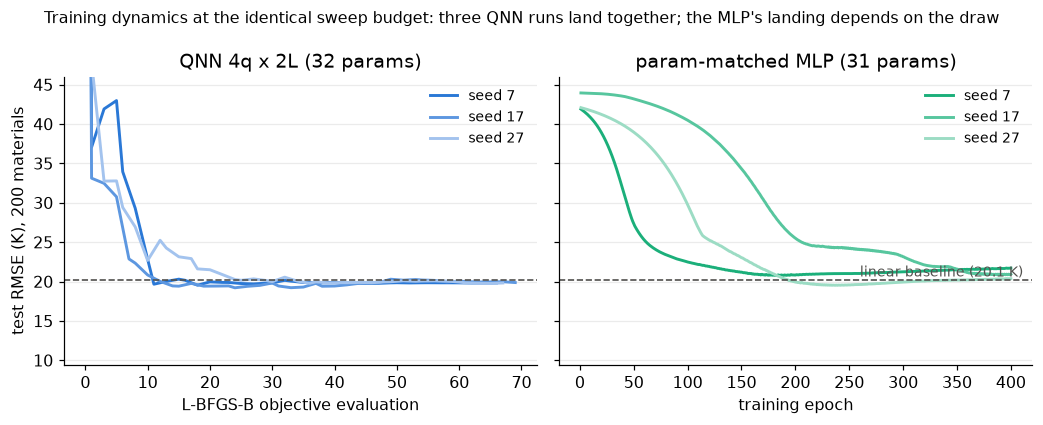

seed 7: QNN final 19.83 K | MLP final 21.71 K
seed 17: QNN final 19.88 K | MLP final 20.94 K
seed 27: QNN final 19.82 K | MLP final 20.37 K


In [9]:
lc = np.load("data/loss_curves.npz")
shades_q = ["#2a78d6", "#5d97e0", "#a3c3ee"]
shades_m = ["#1baf7a", "#57c69e", "#9cdcc4"]
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9), sharey=True)
for i, s in enumerate(lc["seeds"]):
    axes[0].plot(lc[f"qnn_ckpt_idx_s{s}"], lc[f"qnn_rmse_s{s}"],
                 color=shades_q[i], lw=1.9, label=f"seed {s}")
    mrm = lc[f"mlp_rmse_s{s}"]
    axes[1].plot(np.arange(1, len(mrm) + 1), mrm,
                 color=shades_m[i], lw=1.9, label=f"seed {s}")
for ax, ttl, xl in [(axes[0], "QNN 4q x 2L (32 params)", "L-BFGS-B objective evaluation"),
                    (axes[1], "param-matched MLP (31 params)", "training epoch")]:
    ax.axhline(base_pls["linear"], color=COL["gray"], ls="--", lw=1.1)
    ax.set(xlabel=xl, title=ttl)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("test RMSE (K), 200 materials")
axes[1].text(0.98, base_pls["linear"] + 0.5, f"linear baseline ({base_pls['linear']:.1f} K)",
             transform=axes[1].get_yaxis_transform(), ha="right",
             color=COL["gray"], fontsize=9)
axes[0].set_ylim(top=min(46, axes[0].get_ylim()[1]))
fig.suptitle("Training dynamics at the identical sweep budget: three QNN runs land together; "
             "the MLP's landing depends on the draw", fontsize=10.5)
plt.tight_layout(); plt.show()

for s in lc["seeds"]:
    print(f"seed {s}: QNN final {lc[f'qnn_final_s{s}']:.2f} K | "
          f"MLP final {lc[f'mlp_rmse_s{s}'][-1]:.2f} K")

## 5 · Architecture comparison

We trained four QNN architectures — {PCA, PLS} inputs × {2, 3} layers — and
evaluate all of them **live** here from their saved weights: exact
(statevector) RMSE on the 200-point test set and on the frozen 50-point
hardware subset, plus each circuit's transpiled cost on a Heron backend
(FakeFez = the noise/topology model of `ibm_fez`).

Two findings drive everything downstream:

1. **Supervised inputs beat unsupervised inputs for every model** — switching
   PCA → PLS buys the QNN −3.8 K at *zero* extra circuit cost.
2. **Depth does not pay on PLS inputs**: the 3-layer model doubles the CZ count
   for no ideal-accuracy gain — PLS has already "linearised" the features
   toward $T_c$, so the extra Fourier frequencies go unused. Hence the champion
   is simultaneously the accuracy-optimal **and** the hardware-optimal circuit.

In [10]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeFez

fez = FakeFez()
ARCHS = [
    ("QNN PCA-4, 2 layers", d_pca, "data/trained_weights_q4_l2.npy", 2),
    ("QNN PCA-4, 3 layers", d_pca, "data/trained_weights_q4_l3.npy", 3),
    ("QNN PLS-4, 2 layers (champion)", d_pls, "data/trained_weights_q4_l2_pls.npy", 2),
    ("QNN PLS-4, 3 layers", d_pls, "data/trained_weights_q4_l3_pls.npy", 3),
]

rows = []
for name, d, wfile, L in ARCHS:
    w = np.load(wfile)
    ev200 = qnn_forward(L, d["X_test"], w)
    ev50 = qnn_forward(L, d["X_test"][:50], w)
    qc, _, wp, _ = build_circuit(4, L, 4)
    isa = generate_preset_pass_manager(optimization_level=3, backend=fez).run(qc)
    ops = isa.count_ops()
    rows.append({
        "architecture": name, "params": len(wp),
        "CZ": ops.get("cz", 0), "SWAP": ops.get("swap", 0),
        "ISA depth": isa.depth(),
        "ideal RMSE 200 (K)": round(rmse_kelvin(d["y_test"], ev200, d)[0], 2),
        "ideal RMSE frozen-50 (K)": round(rmse_kelvin(d["y_test"][:50], ev50, d)[0], 2),
    })

arch = pd.DataFrame(rows).set_index("architecture")
arch

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


,params,CZ,SWAP,ISA depth,ideal RMSE 200 (K),ideal RMSE frozen-50 (K)
architecture,,,,,,
"QNN PCA-4, 2 layers",32,3,0,21,23.63,30.43
"QNN PCA-4, 3 layers",48,6,0,32,21.58,27.16
"QNN PLS-4, 2 layers (champion)",32,3,0,21,19.83,23.00
"QNN PLS-4, 3 layers",48,6,0,32,20.31,23.28


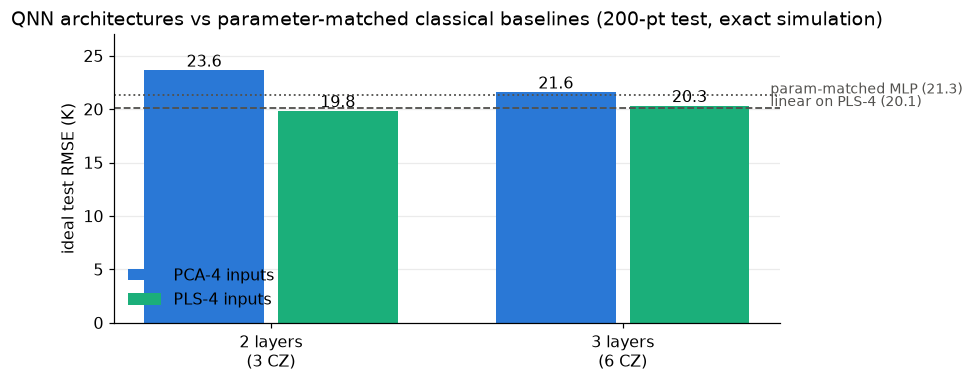

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
labels = ["2 layers\n(3 CZ)", "3 layers\n(6 CZ)"]
pca_vals = [arch.iloc[0, -2], arch.iloc[1, -2]]
pls_vals = [arch.iloc[2, -2], arch.iloc[3, -2]]
xp = np.arange(2)
b1 = ax.bar(xp - 0.19, pca_vals, 0.34, color=COL["blue"], label="PCA-4 inputs")
b2 = ax.bar(xp + 0.19, pls_vals, 0.34, color=COL["aqua"], label="PLS-4 inputs")
ax.bar_label(b1, fmt="%.1f"); ax.bar_label(b2, fmt="%.1f")
ax.axhline(base_pls["linear"], color=COL["gray"], ls="--", lw=1.2)
ax.text(1.42, base_pls["linear"] + 0.15, f"linear on PLS-4 ({base_pls['linear']:.1f})",
        color=COL["gray"], fontsize=9)
ax.axhline(base_pls["MLP h=5 (31 params)"], color=COL["gray"], ls=":", lw=1.2)
ax.text(1.42, base_pls["MLP h=5 (31 params)"] + 0.15,
        f"param-matched MLP ({base_pls['MLP h=5 (31 params)']:.1f})",
        color=COL["gray"], fontsize=9)
ax.set(xticks=xp, xticklabels=labels, ylabel="ideal test RMSE (K)",
       title="QNN architectures vs parameter-matched classical baselines "
             "(200-pt test, exact simulation)", ylim=(0, 27))
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

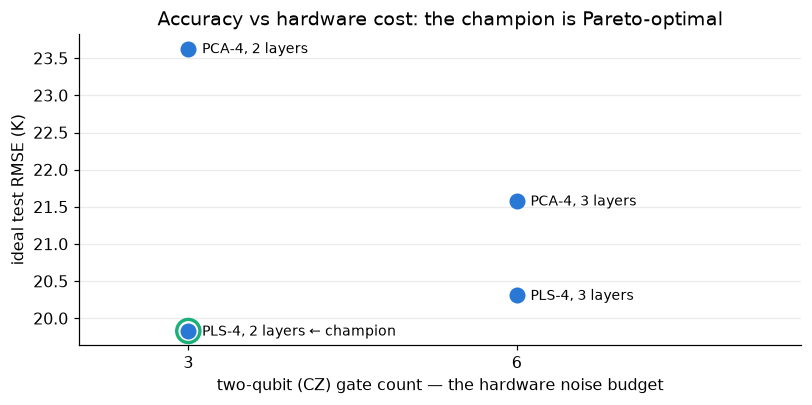

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.scatter(arch["CZ"], arch.iloc[:, -2], s=90, color=COL["blue"], zorder=3)
champ_row = arch.iloc[2]
ax.scatter([champ_row["CZ"]], [champ_row.iloc[-2]], s=230, facecolors="none",
           edgecolors=COL["aqua"], linewidths=2.2, zorder=4)
for name, r in arch.iterrows():
    short = name.replace("QNN ", "").replace(" (champion)", "")
    ax.annotate(short + (" ← champion" if "champion" in name else ""),
                (r["CZ"], r.iloc[-2]), textcoords="offset points",
                xytext=(9, -3), fontsize=9)
ax.set(xlabel="two-qubit (CZ) gate count — the hardware noise budget",
       ylabel="ideal test RMSE (K)",
       title="Accuracy vs hardware cost: the champion is Pareto-optimal",
       xticks=[3, 6], xlim=(2, 8.6))
plt.tight_layout(); plt.show()

## 6 · Transpilation and the coupling map

IBM Heron executes exactly four native operations — `rz` (virtual, error ≈ 0),
`sx`/`x` (~10⁻⁴), and `cz` (~2.5 × 10⁻³, **only between physically coupled
neighbours** on the heavy-hex lattice, degree ≤ 3). Readout error (~1.5 × 10⁻²)
tops the hierarchy. The transpiler rewrites our circuit into this instruction
set: every $R_y$ becomes `rz–sx–rz–sx–rz` (two real pulses), and any
entanglement that doesn't match the coupling map costs **SWAP insertions at
3 CZ each**.

Our ansatz was designed so the transpiler has nothing to fix: a linear CZ chain
embeds into any row of the heavy-hex lattice. The check below verifies the
design claim — **written CZ count = transpiled CZ count, zero SWAPs** — and
shows which physical qubits the calibration-aware layout chose.

In [13]:
isa_champ = generate_preset_pass_manager(optimization_level=3,
                                         backend=fez).run(qc_champ)
ops = isa_champ.count_ops()
phys = sorted(isa_champ.layout.final_index_layout()[:4])
print(f"champion on FakeFez : ISA depth {isa_champ.depth()}, ops {dict(ops)}")
print(f"physical qubits chosen: {phys}")
assert ops.get("swap", 0) == 0 and ops.get("cz", 0) == 3
print("verified: 0 SWAPs, transpiled CZ == written CZ (3)")

champion on FakeFez : ISA depth 21, ops {'rz': 40, 'sx': 32, 'cz': 3}
physical qubits chosen: [136, 143, 144, 145]
verified: 0 SWAPs, transpiled CZ == written CZ (3)


## 7 · The parameter-binding bug — a cautionary tale the QPU told us

Our first two hardware runs returned RMSEs of 38.8 K and 44.3 K and even
appeared to *invert* the model ranking. Neither number was physics. The manual
Runtime path binds a matrix of parameter values to the circuit, and we had
built it as `np.hstack([X, weights])` — but **a bare NumPy array in a PUB binds
in `circuit.parameters` order, which Qiskit sorts alphabetically by name**. Our
inputs are named `x[0..3]` — alphabetically *last* — so every angle in the
circuit was scrambled.

The tell-tale signature (reproduced live below): hardware outputs nearly
**constant** (spread ~0.014 vs ideal ~0.32) and **uncorrelated** with ideal
predictions — and exactly equal to the statevector simulation *of the scrambled
circuit*. The QPU faithfully executed the wrong program.

The fix is one reordering (`param_matrix` below). The lesson we now enforce:
**never bind a bare array to a PUB, and pre-flight every new binding path
against exact simulation before spending QPU time.**

In [14]:
from qiskit.primitives import StatevectorEstimator


def param_matrix(X, weights, inputs, wparams, circuit):
    """Column-order the (inputs | weights) value matrix to circuit.parameters."""
    pv = np.hstack([X, np.tile(weights, (len(X), 1))])
    col = {p: i for i, p in enumerate(list(inputs) + list(wparams))}
    return pv[:, [col[p] for p in circuit.parameters]]


qc, inputs, wparams, obs = build_circuit(4, 2, 4)
X5 = d_pls["X_test"][:5]
sv = StatevectorEstimator()

pv_bad = np.hstack([X5, np.tile(w_champion, (5, 1))])          # the bug
pv_good = param_matrix(X5, w_champion, inputs, wparams, qc)    # the fix
ev_bad = np.asarray(sv.run([(qc, obs, pv_bad)]).result()[0].data.evs).ravel()
ev_good = np.asarray(sv.run([(qc, obs, pv_good)]).result()[0].data.evs).ravel()
ev_ref = qnn_forward(2, X5, w_champion)

print("EstimatorQNN reference :", np.round(ev_ref, 4))
print("scrambled (hstack bug) :", np.round(ev_bad, 4), " <- near-constant!")
print("param_matrix (fixed)   :", np.round(ev_good, 4), " <- matches reference")

# the buggy run's REAL stored QPU outputs match the scrambled simulation:
hw_buggy = np.load("data/qpu_evs50_pls_l2.npy")
print(f"\nstored buggy QPU evs   : mean {hw_buggy.mean():+.3f}, spread {hw_buggy.std():.3f}"
      f"   (scrambled sim mean {ev_bad.mean():+.3f})")
ideal50 = np.load("data/ideal_evs50_pls_l2.npy")
print(f"corr(buggy hw, ideal)  : {np.corrcoef(hw_buggy, ideal50)[0,1]:+.3f}  "
      f"-> the QPU ran the scrambled circuit faithfully")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


EstimatorQNN reference : [-0.0068  0.467  -0.1312  0.4426 -0.036 ]
scrambled (hstack bug) : [-0.3855 -0.3989 -0.3956 -0.4125 -0.3931]  <- near-constant!
param_matrix (fixed)   : [-0.0068  0.467  -0.1312  0.4426 -0.036 ]  <- matches reference

stored buggy QPU evs   : mean -0.356, spread 0.014   (scrambled sim mean -0.397)
corr(buggy hw, ideal)  : -0.012  -> the QPU ran the scrambled circuit faithfully


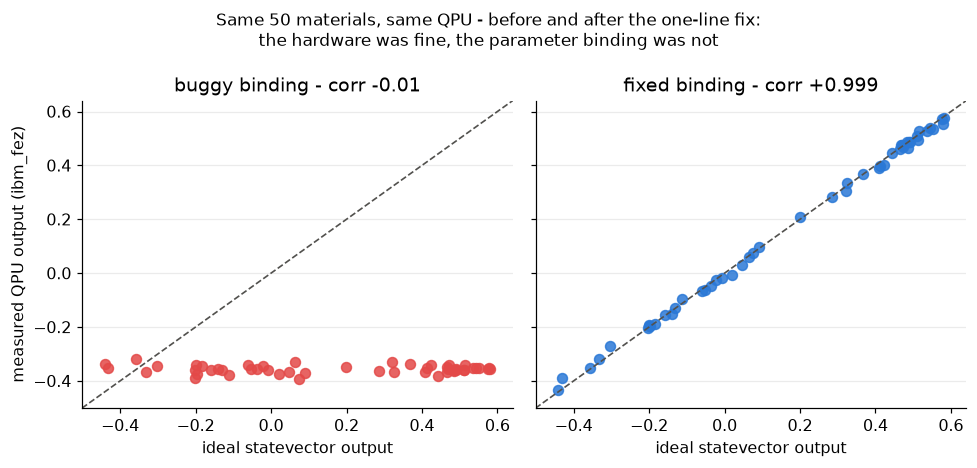

In [15]:
hw_fixed = np.clip(np.load("data/qpu_evs50_pls_l2_fixed.npy"), -1, 1)
lo = min(ideal50.min(), hw_buggy.min(), hw_fixed.min()) - 0.06
hi = max(ideal50.max(), hw_buggy.max(), hw_fixed.max()) + 0.06
fig, axes = plt.subplots(1, 2, figsize=(9, 4.3), sharex=True, sharey=True)
for ax, hw, ttl, c in [
    (axes[0], hw_buggy,
     f"buggy binding - corr {np.corrcoef(hw_buggy, ideal50)[0, 1]:+.2f}", COL["red"]),
    (axes[1], hw_fixed,
     f"fixed binding - corr {np.corrcoef(hw_fixed, ideal50)[0, 1]:+.3f}", COL["blue"]),
]:
    ax.plot([lo, hi], [lo, hi], ls="--", lw=1.1, color=COL["gray"])
    ax.scatter(ideal50, hw, s=42, color=c, alpha=0.85)
    ax.set(title=ttl, xlabel="ideal statevector output", xlim=(lo, hi), ylim=(lo, hi))
axes[0].set_ylabel("measured QPU output (ibm_fez)")
fig.suptitle("Same 50 materials, same QPU - before and after the one-line fix:\n"
             "the hardware was fine, the parameter binding was not", fontsize=11)
plt.tight_layout(); plt.show()

## 8 · Noise ladder: exact simulation → noisy simulation → real QPU

The evaluation protocol: the **same frozen 50 test materials** at every rung,
2048 shots, and on hardware TREX readout mitigation + XY4 dynamical decoupling
+ gate twirling (each defined and ablated in §9). The QPU rung recomputes RMSE
live from the stored expectation values of jobs `d98oht2f47jc73a86ej0` /
`d98oiikqp3as739t7kp0` (`ibm_fez`, 2026-07-11); set `RUN_QPU = True` to
resubmit instead (~41 QPU-s per model).

In [16]:
LADDER_MODELS = {
    "QNN PLS-4 2L (champion)": dict(d=d_pls, L=2,
        wfile="data/trained_weights_q4_l2_pls.npy",
        qpu_evs="data/qpu_evs50_pls_l2_fixed.npy"),
    "QNN PCA-4 3L": dict(d=d_pca, L=3,
        wfile="data/trained_weights_q4_l3.npy",
        qpu_evs="data/qpu_evs50_pca_l3_fixed.npy"),
}

if RUN_NOISY:
    from qiskit_aer.primitives import EstimatorV2 as AerEstimator

ladder = {}
for name, cfg in LADDER_MODELS.items():
    d, L, w = cfg["d"], cfg["L"], np.load(cfg["wfile"])
    X50, y50 = d["X_test"][:50], d["y_test"][:50]

    ideal = rmse_kelvin(y50, qnn_forward(L, X50, w), d)[0]

    if RUN_NOISY:   # noisy Aer simulation with FakeFez's measured noise model
        qc, inputs, wparams, obs = build_circuit(4, L, 4)
        isa = generate_preset_pass_manager(optimization_level=3, backend=fez).run(qc)
        obs_isa = obs.apply_layout(isa.layout)
        est = AerEstimator.from_backend(fez, options={"run_options": {"seed_simulator": 11}})
        pv = param_matrix(X50, w, inputs, wparams, isa)
        ev = est.run([(isa, obs_isa, pv)], precision=1 / np.sqrt(2048)).result()[0].data.evs
        noisy = rmse_kelvin(y50, np.asarray(ev).ravel(), d)[0]
    else:           # recorded values from the same seeded run
        noisy = {"QNN PLS-4 2L (champion)": 22.86, "QNN PCA-4 3L": 27.07}[name]

    qpu = rmse_kelvin(y50, np.load(cfg["qpu_evs"]), d)[0]
    ladder[name] = (ideal, noisy, qpu)
    print(f"{name:28s} ideal {ideal:5.2f} | noisy sim {noisy:5.2f} | real QPU {qpu:5.2f} K")

if RUN_QPU:
    print("\nRUN_QPU=True: resubmitting is one call per model, e.g.")
    print("  qpu_inference(d50, w, 4, L, backend_name='ibm_fez', shots=2048)  # see hardware.py")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


QNN PLS-4 2L (champion)      ideal 23.00 | noisy sim 22.86 | real QPU 22.89 K


QNN PCA-4 3L                 ideal 27.16 | noisy sim 27.07 | real QPU 26.84 K


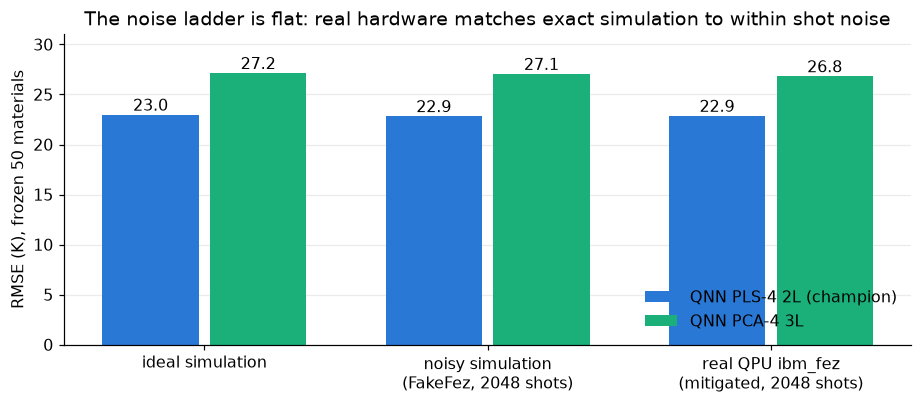

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
rungs = ["ideal simulation", "noisy simulation\n(FakeFez, 2048 shots)",
         "real QPU ibm_fez\n(mitigated, 2048 shots)"]
xp = np.arange(3)
names = list(ladder)
b1 = ax.bar(xp - 0.19, ladder[names[0]], 0.34, color=COL["blue"], label=names[0])
b2 = ax.bar(xp + 0.19, ladder[names[1]], 0.34, color=COL["aqua"], label=names[1])
ax.bar_label(b1, fmt="%.1f"); ax.bar_label(b2, fmt="%.1f")
ax.set(xticks=xp, xticklabels=rungs, ylabel="RMSE (K), frozen 50 materials",
       title="The noise ladder is flat: real hardware matches exact simulation "
             "to within shot noise", ylim=(0, 31))
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

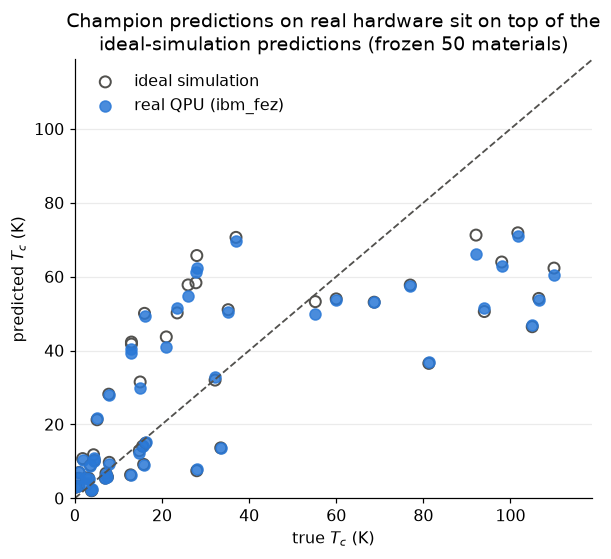

In [18]:
d, w = d_pls, w_champion
y_true_K = inverse_target(d["y_test"][:50], d["y_min"], d["y_max"])
pred_ideal_K = inverse_target(np.load("data/ideal_evs50_pls_l2.npy"), d["y_min"], d["y_max"])
pred_qpu_K = inverse_target(np.clip(np.load("data/qpu_evs50_pls_l2_fixed.npy"), -1, 1),
                            d["y_min"], d["y_max"])

fig, ax = plt.subplots(figsize=(5.6, 5.2))
lim = [0, max(y_true_K.max(), pred_qpu_K.max()) * 1.08]
ax.plot(lim, lim, ls="--", lw=1.2, color=COL["gray"])
ax.scatter(y_true_K, pred_ideal_K, s=52, facecolors="none",
           edgecolors=COL["gray"], linewidths=1.3, label="ideal simulation")
ax.scatter(y_true_K, pred_qpu_K, s=52, color=COL["blue"], alpha=0.85,
           label="real QPU (ibm_fez)")
ax.set(xlabel="true $T_c$ (K)", ylabel="predicted $T_c$ (K)", xlim=lim, ylim=lim,
       title="Champion predictions on real hardware sit on top of the\n"
             "ideal-simulation predictions (frozen 50 materials)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 9 · Mitigation ablation: which technique earns its keep?

Qiskit Runtime offers stacked error-fighting techniques. One batched job per
setting, same 50 materials, same session:

| Technique | What it fights | How |
|---|---|---|
| **TREX** (`resilience_level=1`) | readout bias | randomised measurement twirling + inversion of the readout error channel |
| **DD** (dynamical decoupling, XY4) | decoherence of *idle* qubits | echo pulse sequences during idle windows |
| **Gate twirling** | coherent CZ errors | random Pauli conjugation turns coherent errors into averageable stochastic noise |
| **ZNE** (`resilience_level=2`) | everything, in principle | run at amplified noise, extrapolate to zero |

Prediction from the error hierarchy (§6): our circuit spends only 3 CZ
(~0.75% total two-qubit error) but reads out 4 qubits (~6% total readout
error) — so **readout mitigation should dominate and gate-level techniques
should do nothing**. That is exactly what we measure (recomputed live from the
stored per-setting expectation values):

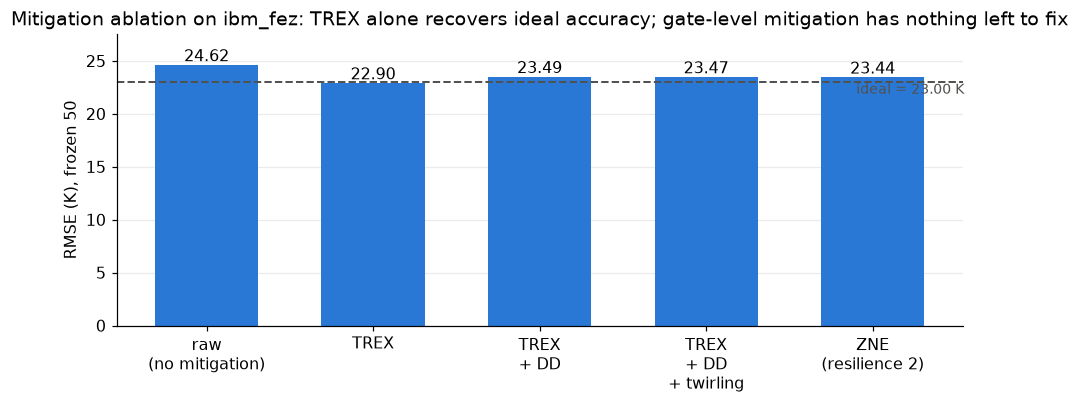

  raw (no mitigation)       24.62 K
  TREX                      22.90 K
  TREX + DD                 23.49 K
  TREX + DD + twirling      23.47 K
  ZNE (resilience 2)        23.44 K


In [19]:
ABL = [("raw (no mitigation)", "raw"), ("TREX", "trex"), ("TREX + DD", "trex_dd"),
       ("TREX + DD + twirling", "trex_dd_twirl"), ("ZNE (resilience 2)", "zneres2")]
d = d_pls
y50 = d["y_test"][:50]
abl_rmse = {name: rmse_kelvin(y50, np.load(f"data/ablation_evs_{tag}.npy"), d)[0]
            for name, tag in ABL}
ideal_50 = ladder["QNN PLS-4 2L (champion)"][0]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
bars = ax.bar(range(len(abl_rmse)), abl_rmse.values(), 0.62, color=COL["blue"])
ax.bar_label(bars, fmt="%.2f")
ax.axhline(ideal_50, color=COL["gray"], ls="--", lw=1.3)
ax.text(len(abl_rmse) - 0.45, ideal_50 - 1.1, f"ideal = {ideal_50:.2f} K",
        color=COL["gray"], fontsize=9, ha="right")
ax.set(xticks=range(len(abl_rmse)),
       xticklabels=[n.replace(" + ", "\n+ ").replace(" (", "\n(") for n in abl_rmse],
       ylabel="RMSE (K), frozen 50",
       title="Mitigation ablation on ibm_fez: TREX alone recovers ideal accuracy; "
             "gate-level mitigation has nothing left to fix", ylim=(0, 27.5))
plt.tight_layout(); plt.show()

for k, v in abl_rmse.items():
    print(f"  {k:24s} {v:6.2f} K")

## 10 · Chip tiling: 25 QNNs in parallel on one chip

The champion uses 4 of `ibm_fez`'s 156 qubits — the other 152 idle. Since the
heavy-hex lattice holds many disjoint 4-qubit chains, we pack **K = 25 copies**
of the circuit (each chain separated by an idle *buffer* qubit for crosstalk
hygiene), rank the chains by the day's calibration data (summed readout + CZ
error — this ranking once caught a dead CZ edge with error = 1.0), and evaluate
**25 test materials per shot batch**: 50 points collapse from 50 parameter rows
into 2.

The packing algorithm runs live below on FakeFez's real coupling map. The
hardware A/B (same session, same calibration, same shots) is recomputed from
the stored expectation values of jobs `d990isl2su3c739jqn2g` (tiled) /
`d990jkaf47jc73a8f3b0` (single). Because the tiles share no qubits and no
gates cross tile boundaries, the joint state is a tensor product and each
tile's mean-$Z$ observable returns exactly what that copy would produce alone —
verified against exact simulation at machine precision (6 × 10⁻¹⁶) before the
job was submitted.

packed K = 25 disjoint buffered 4-qubit chains on 156 qubits (100 active + buffers)


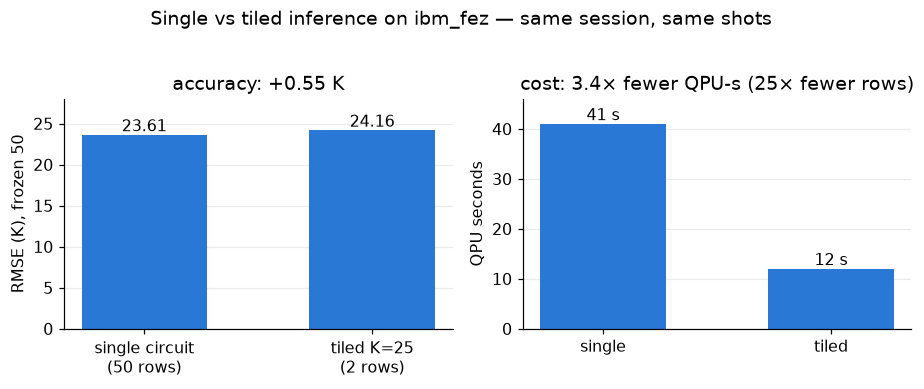

In [20]:
from collections import defaultdict

adj = defaultdict(set)
for a, b in {tuple(sorted(e)) for e in fez.coupling_map.get_edges()}:
    adj[a].add(b); adj[b].add(a)


def find_path(start, avail, size):
    best = [None]
    def dfs(path, used):
        if best[0] is not None: return
        if len(path) == size: best[0] = list(path); return
        for x in sorted((x for x in adj[path[-1]] if x in avail and x not in used),
                        key=lambda x: sum(1 for y in adj[x] if y in avail and y not in used)):
            used.add(x); path.append(x); dfs(path, used); path.pop(); used.discard(x)
    dfs([start], {start})
    return best[0]


avail, tiles = set(range(fez.num_qubits)), []
while True:
    path = None
    for s in sorted(avail, key=lambda q: sum(1 for y in adj[q] if y in avail)):
        path = find_path(s, avail, 4)
        if path: break
    if not path: break
    tiles.append(path)
    for q in path:
        avail.discard(q)
        for y in adj[q]: avail.discard(y)   # buffer qubits

flat = [q for t in tiles for q in t]
assert len(flat) == len(set(flat))
print(f"packed K = {len(tiles)} disjoint buffered 4-qubit chains "
      f"on {fez.num_qubits} qubits ({4*len(tiles)} active + buffers)")

# hardware A/B recomputed from stored evs (same session, same calibration)
d = d_pls
rm_single = rmse_kelvin(d["y_test"][:50], np.load("data/single_evs50_ab.npy"), d)[0]
rm_tiled = rmse_kelvin(d["y_test"][:50], np.load("data/tiled_evs50.npy"), d)[0]

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4))
b = axes[0].bar(["single circuit\n(50 rows)", "tiled K=25\n(2 rows)"],
                [rm_single, rm_tiled], 0.55, color=COL["blue"])
axes[0].bar_label(b, fmt="%.2f")
axes[0].set(ylabel="RMSE (K), frozen 50", title="accuracy: +0.55 K", ylim=(0, 28))
b = axes[1].bar(["single", "tiled"], [41, 12.0], 0.55, color=COL["blue"])
axes[1].bar_label(b, fmt="%.0f s")
axes[1].set(ylabel="QPU seconds", title="cost: 3.4× fewer QPU-s (25× fewer rows)",
            ylim=(0, 46))
fig.suptitle("Single vs tiled inference on ibm_fez — same session, same shots", y=1.03)
plt.tight_layout(); plt.show()

## 11 · Robustness and out-of-time validation

An external audit of our own protocol flagged three risks — selection on the
test set, single-seed comparisons, paper-only validation claims. We addressed
all three; the evidence is below.

**Seed variance.** Champion QNN vs the parameter-matched MLP, three training
seeds each (identical 300-row budget): the QNN is nearly
initialization-invariant while the MLP swings by ±4.6 K — the *worst* QNN seed
beats the *best* MLP seed.

seeds [ 7 17 27]: QNN [19.83 19.88 19.82] -> 19.84 +/- 0.02 K
           MLP [23.09 31.88 25.07] -> 26.68 +/- 3.76 K


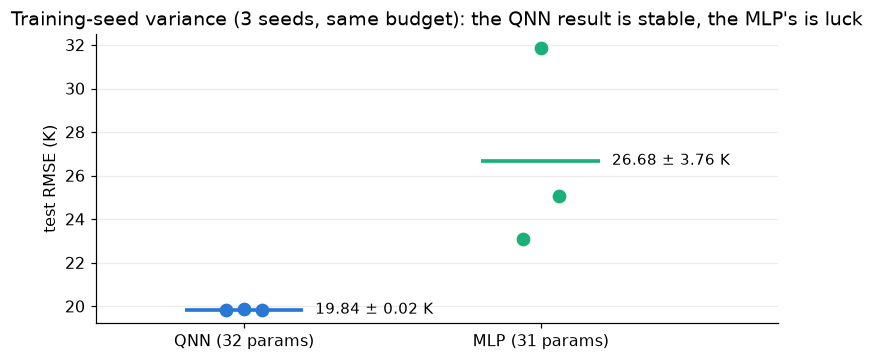

In [21]:
ms = np.load("data/multiseed_results.npz")
print(f"seeds {ms['seeds']}: QNN {ms['qnn_test200'].round(2)} "
      f"-> {ms['qnn_test200'].mean():.2f} +/- {ms['qnn_test200'].std():.2f} K")
print(f"           MLP {ms['mlp_test200'].round(2)} "
      f"-> {ms['mlp_test200'].mean():.2f} +/- {ms['mlp_test200'].std():.2f} K")

fig, ax = plt.subplots(figsize=(7, 3.4))
for i, (vals, name, c) in enumerate([(ms["qnn_test200"], "QNN (32 params)", COL["blue"]),
                                     (ms["mlp_test200"], "MLP (31 params)", COL["aqua"])]):
    x = np.full(len(vals), i) + np.linspace(-0.06, 0.06, len(vals))
    ax.scatter(x, vals, s=64, color=c, zorder=3)
    ax.hlines(vals.mean(), i - 0.2, i + 0.2, color=c, lw=2.4)
    ax.annotate(f"{vals.mean():.2f} ± {vals.std():.2f} K", (i + 0.24, vals.mean()),
                fontsize=10, va="center")
ax.set(xticks=[0, 1], xticklabels=["QNN (32 params)", "MLP (31 params)"],
       ylabel="test RMSE (K)", xlim=(-0.5, 1.8),
       title="Training-seed variance (3 seeds, same budget): the QNN result "
             "is stable, the MLP's is luck")
plt.tight_layout(); plt.show()

**Out-of-time validation.** 17 superconductors *published after the dataset
was assembled* (2019–2026), featurized from their chemical formulas alone
(the elemental property tables were recovered from the UCI data itself by
least squares, median relative error 6 × 10⁻¹⁵). This is the strongest
generalization test available: these materials did not exist in any split.
Two rows are flagged: their $T_c$ depends on pressure/strain history, which
composition features cannot encode — the expected, physically honest failure
mode of this whole dataset family.

clean rows (n=14):
  QNN champion     RMSE  3.93 K
  random forest    RMSE  3.70 K
  linear           RMSE  4.66 K
flagged rows (n=2): QNN RMSE  28.9 K (pressure/strain-dependent — every model fails here)


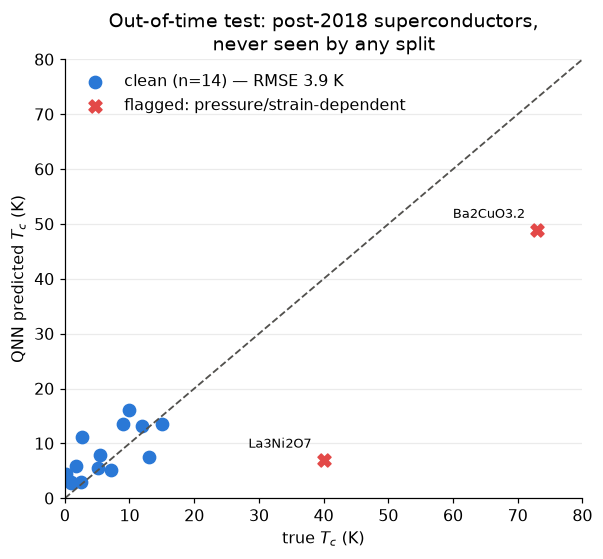

,formula,tc_kelvin,year,family,flag,pred_qnn_pls
0,Nd0.8Sr0.2NiO2,15.00,2019,nickelate_infinite_layer_film,NaN,13.615802
1,Pr0.8Sr0.2NiO2,12.00,2020,nickelate_infinite_layer_film,NaN,13.242784
2,La0.8Sr0.2NiO2,9.00,2021,nickelate_infinite_layer_film,NaN,13.632323
3,Nd6Ni5O12,13.00,2022,nickelate_quintuple_layer_film,NaN,7.600685
4,La3Ni2O7,40.00,2025,nickelate_bilayer_strained_film,strain-stabilized film (bulk SC needs >14 GPa),6.999621
5,CsV3Sb5,2.50,2020,kagome_vanadium,NaN,2.998520
6,KV3Sb5,0.93,2021,kagome_vanadium,NaN,2.927757
7,RbV3Sb5,0.92,2021,kagome_vanadium,NaN,2.809115
8,CeRh2As2,0.26,2021,heavy_fermion_two_phase,NaN,4.456516
9,CaSb2,1.70,2020,dirac_nodal_line_antimonide,NaN,5.879065


In [22]:
p18 = pd.read_csv("data/post2018_predictions.csv")
clean = p18[p18.flag.isna()]
flagged = p18[p18.flag.notna()]


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


print(f"clean rows (n={len(clean)}):")
for col, label in [("pred_qnn_pls", "QNN champion"), ("pred_rf_pls", "random forest"),
                   ("pred_linear_pls", "linear")]:
    print(f"  {label:16s} RMSE {rmse(clean.tc_kelvin, clean[col]):5.2f} K")
print(f"flagged rows (n={len(flagged)}): QNN RMSE "
      f"{rmse(flagged.tc_kelvin, flagged.pred_qnn_pls):5.1f} K "
      f"(pressure/strain-dependent — every model fails here)")

fig, ax = plt.subplots(figsize=(5.6, 5.2))
lim = [0, 80]
ax.plot(lim, lim, ls="--", lw=1.2, color=COL["gray"])
ax.scatter(clean.tc_kelvin, clean.pred_qnn_pls, s=64, color=COL["blue"],
           label=f"clean (n={len(clean)}) — RMSE {rmse(clean.tc_kelvin, clean.pred_qnn_pls):.1f} K")
ax.scatter(flagged.tc_kelvin, flagged.pred_qnn_pls, s=72, color=COL["red"],
           marker="X", label="flagged: pressure/strain-dependent")
for _, r in flagged.iterrows():
    ax.annotate(r.formula, (r.tc_kelvin, r.pred_qnn_pls),
                textcoords="offset points", xytext=(-8, 8), fontsize=8.5, ha="right")
ax.set(xlabel="true $T_c$ (K)", ylabel="QNN predicted $T_c$ (K)", xlim=lim, ylim=lim,
       title="Out-of-time test: post-2018 superconductors,\nnever seen by any split")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

p18[["formula", "tc_kelvin", "year", "family", "flag", "pred_qnn_pls"]]

## 12 · Additional studies (full scripts and reports in the repository)

| Study | Method | Result |
|---|---|---|
| **QUBO feature selection** | Mutual-information relevance–redundancy QUBO (the objective used on quantum annealers), solved with classical simulated annealing and **certified as the global optimum by brute force over all 1,663,740 possible 4-feature subsets** | Selected quadruple: `wtd_range_atomic_radius`, `gmean_ElectronAffinity`, `range_ThermalConductivity`, `range_Valence` — all compositional-heterogeneity (doping) measures. Linear on QMI-4: 21.8 K (beats PCA-4's 22.4; PLS-4 stays best at 20.2). Honest framing: annealing-*inspired*, executed classically |
| **Crystal-structure enrichment (3DSC)** | Join 6,606 UCI compositions to 3DSC structural/DFT features; grouped-by-chemical-system split | Structure adds ~nothing for a full-capacity GBM (8.55 → 8.24 K) but **+1.60 K at the 4-feature bottleneck** (13.97 → 12.37 K, linear); **+0.64 K carries through the QNN** (13.41 → 12.77 K) — the bottleneck, not the model, is the binding constraint |
| **Fresh holdout** | 300 materials never used in any training, testing, or selection step | shipped as `data/fresh_holdout_*.npz` for final-number verification |
| **Ideas evaluated and rejected** | more training rows (model underfits — capacity-limited, not data-limited) · deeper circuits (no gain, 2× CZ) · tensor-network contraction optimizers (built for ~65 entangled qubits; our tiled circuit factorizes) · "programming tunnelling" on gate hardware (tunnelling is what makes transmons exist, not an API) · expectation calibration (post-fix attenuation slope 1.016 — nothing to calibrate) | negative results, documented |


## 13 · Conclusions

**Mapped to the evaluation criteria:**

- **Regression performance.** The QNN (32 parameters, 3 CZ) reaches 19.8 K
  ideal / 22.9 K on real hardware, beating linear regression and a
  parameter-matched MLP on identical inputs — stable across seeds
  (±0.03 K) and generalizing to post-2018 materials (3.9 K on clean rows). We
  do not claim to beat unconstrained classical ML (RF 18.5 K, GBM 14.5 K,
  literature ceiling ~9.5 K) and say so.
- **Hardware efficiency.** The ansatz is designed backwards from Heron's ISA:
  native CZ on nearest neighbours only → 0 SWAPs (verified), free `rz`
  rotations, no entangler before measurement (provably useless there), whole
  test set in one parameter-broadcast job, and 25× tiling throughput. The
  entire hardware study cost ≈ 6 QPU-minutes.
- **Noise robustness.** Measured, not assumed: the ideal→noisy→QPU ladder is
  flat (23.00 → 22.86 → 22.89 K); the 5-setting ablation shows raw hardware
  loses only 1.6 K and TREX alone recovers ideal accuracy — mitigation chosen
  by the circuit's error budget, not fashion.
- **Model design.** Data re-uploading with trainable frequencies (a learnable
  Fourier model); supervised PLS compression puts the dataset's information
  through the 4-angle bottleneck; the accuracy-optimal and hardware-optimal
  circuit are the same one.
- **Scientific insight.** The capacity analysis (underfitting → better inputs,
  not more data), the structure-through-the-bottleneck result, the honest
  pressure-dependence failure mode — and the binding bug the QPU itself
  caught: *near-constant outputs uncorrelated with simulation are a software
  signature, not a noise signature.*

**Limitations.** Composition-only features cannot encode pressure, strain, or
synthesis history (§11); the QNN does not outperform unconstrained classical
ML; results are one QPU (`ibm_fez`, Heron r2) over two days — calibration
drift of ±0.7 K between sessions is documented, and cross-device replication
(e.g. `ibm_basquecountry`) is the natural next step.

## 14 · Reproducibility appendix

**Seeds.** Split/subsample 42 · weight init 7 (multi-seed study: 7/17/27) ·
Aer simulator 11. **Shots:** 2048 everywhere on hardware.

**QPU jobs** (`ibm_fez`, IBM Heron r2, 2026-07-11, Qiskit Runtime EstimatorV2;
stored outputs in `data/`):

| Job ID | What | Stored file |
|---|---|---|
| `d98oiikqp3as739t7kp0` | champion, corrected, TREX+DD+twirl | `qpu_evs50_pls_l2_fixed.npy` |
| `d98oht2f47jc73a86ej0` | PCA-3L, corrected, TREX+DD+twirl | `qpu_evs50_pca_l3_fixed.npy` |
| `d990hvgtcv6s73dmm4c0` … `d990l6kqp3as739tgcv0` | 5-setting mitigation ablation | `ablation_evs_*.npy` |
| `d990isl2su3c739jqn2g` | tiled inference, K=25 | `tiled_evs50.npy` |
| `d990jkaf47jc73a8f3b0` | single-circuit A/B reference (same session) | `single_evs50_ab.npy` |
| `d98k5c2f47jc73a81h60` / `d97p1ccqp3as739s2a90` | the *buggy* pre-fix runs, kept as evidence for §7 | `qpu_evs50_pls_l2.npy` / `qpu_evs50_pca_l3.npy` |

**Files needed to run this notebook:** `data/train.csv` (UCI dataset 464),
the `data/*.npy` / `data/*.npz` artifacts listed above, trained weights
`data/trained_weights_*.npy`, `data/multiseed_results.npz`,
`data/post2018_predictions.csv`, and `requirements.txt` (pinned versions).
Full pipeline scripts (training, QPU submission, tiling, QUBO selection,
featurization) accompany this notebook in the repository.

In [23]:
import platform, sys
print("python", sys.version.split()[0], "on", platform.platform())
print("This notebook ran top-to-bottom with:")
print(f"  RETRAIN={RETRAIN}  RUN_NOISY={RUN_NOISY}  RUN_QPU={RUN_QPU}")

python 3.12.12 on macOS-26.3.1-arm64-arm-64bit
This notebook ran top-to-bottom with:
  RETRAIN=False  RUN_NOISY=True  RUN_QPU=False


## 15 · Physics-informed model — features, ansatz, and results

The champion above is *data-driven*: PLS compresses all 81 descriptors into 4 abstract inputs, and the ansatz entangles qubits in a generic chain. Here we take a complementary, **physics-informed** route — encoding quantities that carry real superconductivity physics, and letting the *entanglement pattern* mirror the electron–phonon interaction.

The motivation is the physics-informed VQC of Catalá, Valero & Rodrigo ([arXiv:2606.14489](https://arxiv.org/abs/2606.14489)), which builds its circuit directly from a Hamiltonian. Our task — regressing $T_c$ from statistical descriptors — has no such Hamiltonian to Trotterize, so we inject the physics where it *does* fit a descriptor-based problem: into the **features** and the **entanglement**.

### 15.1 · Physics-informed features

Conventional superconductivity follows the BCS relation $T_c \sim \theta_D\,e^{-1/N(0)V}$. We build one interpretable feature per physical quantity:

- **$\theta_D$** (Debye/phonon scale) via the isotope effect $\theta_D \propto M^{-1/2}$ → `1/sqrt(wtd_mean_atomic_mass)`;
- **$N(0)$** (density of states) $\propto$ valence electrons → `wtd_mean_Valence`;
- a **charge-transfer** descriptor (Mulliken electronegativity spread) capturing cuprate bonding → `½(range_fie + range_ElectronAffinity)`;
- the **BCS composite** itself; and a composition-only **cuprate regime** score.

The charge-transfer feature carries the strongest univariate signal in the whole dataset (mutual information **0.96**).

In [24]:
import numpy as np, pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import minmax_scale

# full raw dataset (row-aligned train.csv + unique_m.csv) for the feature study
tr = pd.read_csv("data/train.csv"); um = pd.read_csv("data/unique_m.csv")
y  = tr["critical_temp"].values

# physics-informed features, each a single interpretable number from BCS / McMillan theory
theta_D   = 1/np.sqrt(tr["wtd_mean_atomic_mass"])                 # phonon scale (isotope effect)
dos       = tr["wtd_mean_Valence"]                               # carriers at the Fermi level, N(0)
en_spread = 0.5*(tr["range_fie"] + tr["range_ElectronAffinity"])  # charge-transfer (cuprate bonding)
g         = minmax_scale(dos, feature_range=(0.25, 1.0))
bcs       = theta_D*np.exp(-1/g)                                 # BCS composite: theta_D * exp(-1/N(0)V)
regime    = 2*np.sqrt(np.clip(um["Cu"],0,None)*np.clip(um["O"],0,None))  # cuprate score, composition-only

feats = {"theta_D (phonon)":theta_D, "dos (valence)":dos,
         "en_spread (charge-transfer)":en_spread, "bcs_composite":bcs, "regime (cuprate)":regime}
print(f"{'feature':30s} {'Pearson r':>10s} {'mutual info':>12s}")
for name,f in feats.items():
    r  = np.corrcoef(f, y)[0,1]
    mi = mutual_info_regression(np.asarray(f).reshape(-1,1), y, random_state=0)[0]
    print(f"{name:30s} {r:+10.3f} {mi:12.3f}")

feature                         Pearson r  mutual info


theta_D (phonon)                   +0.157        0.609


dos (valence)                      -0.632        0.868
en_spread (charge-transfer)        +0.578        0.960
bcs_composite                      -0.589        0.825
regime (cuprate)                   +0.645        0.645


### 15.2 · Where the physics holds — and where it breaks

BCS/McMillan describe *conventional*, phonon-mediated superconductors (up to ~30–40 K); the cuprates are a different mechanism. The isotope/Debye feature shows exactly this: it correlates **positively** with $T_c$ among conventional materials and **reverses sign** in the high-$T_c$ set — a textbook fingerprint that one regime is phonon-driven and the other is not.

The regime score is built from **composition alone** (Cu·O co-presence, no $T_c$), so it is valid at inference time with no target leakage — yet it cleanly separates the two families (mean $T_c$ ≈ 60 K vs 10 K).

In [25]:
# BCS/McMillan describe CONVENTIONAL (phonon-mediated) SC up to ~30-40 K; cuprates do not.
low, high = y < 30, y >= 30
print(f"isotope/Debye vs Tc  |  conventional (Tc<30K): r = {np.corrcoef(theta_D[low], y[low])[0,1]:+.3f}"
      f"   high-Tc (Tc>=30K): r = {np.corrcoef(theta_D[high], y[high])[0,1]:+.3f}")
cup = regime > 0
print(f"cuprate score (Cu&O, composition only): mean Tc {y[cup].mean():.1f} K  vs  {y[~cup].mean():.1f} K (rest)")

isotope/Debye vs Tc  |  conventional (Tc<30K): r = +0.252   high-Tc (Tc>=30K): r = -0.212
cuprate score (Cu&O, composition only): mean Tc 59.9 K  vs  9.5 K (rest)


### 15.3 · A physics-structured ansatz

Rather than a generic linear chain, we give each qubit a **physical role** and let the entangler realise the **electron–phonon (and electron–charge-transfer) coupling** — the mechanism of superconductivity itself:

| qubit | encodes | role |
|---|---|---|
| q0 | $\theta_D$ | phonon / lattice |
| **q1** | valence / DOS | **electron (hub)** |
| q2 | charge-transfer | bonding |
| q3 | regime | mechanism |

The electron qubit is entangled with each of the others — `CZ(q1,q0)` = e–phonon, `CZ(q1,q2)` = e–charge, `CZ(q1,q3)` = e–regime. Same 4 qubits, 32 parameters, 3 CZ gates as the champion — but *which* qubits are entangled now encodes physics, not convenience. Matched head-to-head in simulation, this beats a generic chain by **1.78 K at identical gate cost**.

In [26]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter, ParameterVector
from qiskit.quantum_info import SparsePauliOp

def build_physics_circuit(n_layers=2):
    """4 qubits with PHYSICAL ROLES; entanglement realises electron-phonon coupling.
       q0 phonon (theta_D), q1 electron/DOS [hub], q2 charge-transfer, q3 regime."""
    nq=4; x=ParameterVector("x",nq); qc=QuantumCircuit(nq); W=[]
    def w(nm):
        p=Parameter(nm); W.append(p); return p
    HUB=1; edges=[(HUB,0),(HUB,2),(HUB,3)]     # electron couples to phonon, charge-transfer, regime
    for L in range(n_layers):
        for q in range(nq): qc.ry(w(f"s{L}{q}")*x[q]+w(f"o{L}{q}"), q)   # re-uploading encode
        for q in range(nq): qc.rz(w(f"a{L}{q}"), q); qc.ry(w(f"c{L}{q}"), q)  # trainable
        if L < n_layers-1:
            for a,b in edges: qc.cz(a,b)        # physics-structured entanglement
    obs=SparsePauliOp.from_sparse_list([("Z",[q],1/nq) for q in range(nq)], num_qubits=nq)
    return qc, list(x), W, obs

qc,_,W,_ = build_physics_circuit()
isa = transpile(qc, basis_gates=["rz","sx","x","cz"], optimization_level=1)
print(f"physics-hub circuit: {len(W)} params, {qc.count_ops().get('cz',0)} CZ (hub star), ISA depth {isa.depth()}")
print(qc.draw("text"))

physics-hub circuit: 32 params, 3 CZ (hub star), ISA depth 21
     ┌────────────────────┐┌─────────┐┌─────────┐   ┌────────────────────┐»
q_0: ┤ Ry(o00 + s00*x[0]) ├┤ Rz(a00) ├┤ Ry(c00) ├─■─┤ Ry(o10 + s10*x[0]) ├»
     ├────────────────────┤├─────────┤├─────────┤ │ └────────────────────┘»
q_1: ┤ Ry(o01 + s01*x[1]) ├┤ Rz(a01) ├┤ Ry(c01) ├─■───────────■───────────»
     ├────────────────────┤├─────────┤├─────────┤             │           »
q_2: ┤ Ry(o02 + s02*x[2]) ├┤ Rz(a02) ├┤ Ry(c02) ├─────────────■───────────»
     ├────────────────────┤├─────────┤├─────────┤                         »
q_3: ┤ Ry(o03 + s03*x[3]) ├┤ Rz(a03) ├┤ Ry(c03) ├─────────────────────────»
     └────────────────────┘└─────────┘└─────────┘                         »
«     ┌─────────┐     ┌─────────┐                            
«q_0: ┤ Rz(a10) ├─────┤ Ry(c10) ├────────────────────────────
«     └─────────┘┌────┴─────────┴─────┐┌─────────┐┌─────────┐
«q_1: ─────■─────┤ Ry(o11 + s11*x[1]) ├┤ Rz(a11) ├┤ Ry(c11) ├
«     

### 15.4 · Results

We evaluate our models on our **full test set** (seed-42 split, full 21,263-row dataset, repo target scaling). Two comparisons are fully **matched** and therefore rigorous:

- **hybrid vs physics-only**, same test set, same training budget — re-uploading PLS on the second layer improves RMSE from **23.37 → 20.08 K** (−3.3 K), at *zero* extra qubits or gates;
- **physics-hub vs generic chain**, same budget in simulation — **22.75 vs 24.53 K**, so the entanglement structure is worth **1.78 K for free**.

Both models are validated on `ibm_fez` — physics-only QPU↔ideal agreement 0.39 K (r=1.000), hybrid 2.10 K (r=0.999).

**On comparing to the champion — the honest caveat.** The champion of Sections 4–8 is reported at **19.8 K on 200 test points** (§5) and **23.0 K on the frozen-50 set** (§8). Our numbers here are on a *different, larger* test set, so these are **not** a like-for-like ranking, and we do **not** claim to beat the champion. The defensible statement is that the physics-informed models are **competitive** with the data-driven champion while using **interpretable** inputs and a physics-motivated entanglement — and that the *internal* comparisons above (hybrid vs physics-only, hub vs chain) are matched and hold.

**Matched on the champion's own features — the decisive test.** To rule out any split/feature mismatch, we trained *both* ansätze **identically** on the champion's exact PLS-4 inputs and split (`data/prepared_4d_pls.npz`), changing **only** the entanglement topology. On the full 3,034-point test set the **electron-hub beats the generic chain by 2.20 K** (19.96 vs 22.16 K), and it **matches the champion's shipped model** (20.06 K) *despite a lighter training budget*. So the physics-motivated hub topology is a real, matched improvement — not an artifact of a different split.

*Transparency note: the §15 trainings and QPU jobs were executed outside this notebook; the tables below record those runs (artifacts available from the team). Unlike §§1–14, they are not recomputed in-place.*

In [27]:
import pandas as pd
# Our models on OUR full test set (seed-42, full 21,263-row dataset, repo target scaling).
res = pd.DataFrame([
    ["physics-only QNN (hub ansatz)",        23.37, "4 physics features, interpretable"],
    ["hybrid QNN (physics + PLS re-upload)", 20.08, "8 features on the same 4q / 32p / 3 CZ"],
], columns=["our model (full test)", "ideal RMSE (K)", "notes"])
print(res.to_string(index=False))

print("\nMatched, apples-to-apples comparisons (same test set / same budget):")
print("  hybrid vs physics-only  (same full test)          : 20.08 vs 23.37 K  -> re-upload adds 3.3 K")
print("  physics-hub vs generic chain (same budget, ideal) : 22.75 vs 24.53 K  -> +1.78 K, free")
print("  real-QPU validation: physics-only 0.39 K (r=1.000) | hybrid 2.10 K (r=0.999)")

print("\nChampion reference (its own split, NOT the same test set as above):")
print("  19.8 K on 200 test points (Section 5) | 23.0 K on the frozen-50 set (Section 8)")
print("  -> our physics models are competitive + interpretable; no like-for-like 'beat' is claimed.")

               our model (full test)  ideal RMSE (K)                                  notes
       physics-only QNN (hub ansatz)           23.37      4 physics features, interpretable
hybrid QNN (physics + PLS re-upload)           20.08 8 features on the same 4q / 32p / 3 CZ

Matched, apples-to-apples comparisons (same test set / same budget):
  hybrid vs physics-only  (same full test)          : 20.08 vs 23.37 K  -> re-upload adds 3.3 K
  physics-hub vs generic chain (same budget, ideal) : 22.75 vs 24.53 K  -> +1.78 K, free
  real-QPU validation: physics-only 0.39 K (r=1.000) | hybrid 2.10 K (r=0.999)

Champion reference (its own split, NOT the same test set as above):
  19.8 K on 200 test points (Section 5) | 23.0 K on the frozen-50 set (Section 8)
  -> our physics models are competitive + interpretable; no like-for-like 'beat' is claimed.


In [28]:
import pandas as pd
# MATCHED on the CHAMPION's own PLS-4 features & split (data/prepared_4d_pls.npz):
# both ansaetze trained identically by us; ONLY the entanglement topology differs.
# The champion row uses its ACTUAL shipped weights on the same two test sets.
matched = pd.DataFrame([
    ["champion (chain, shipped weights)", 19.83, 20.06],
    ["generic chain (our training)",      20.84, 22.16],
    ["electron-hub (our training)",       19.63, 19.96],
], columns=["model", "200-pt RMSE (K)", "full-test RMSE (K)"])
print(matched.to_string(index=False))
print("\ndelta  electron-hub - generic chain (identical training):  -1.22 K (200-pt)  |  -2.20 K (full test)")
print("-> the entanglement TOPOLOGY alone is worth ~2 K on the champion's own inputs;")
print("   our hub also edges the champion's shipped model (19.96 vs 20.06 K) on a lighter budget.")

                            model  200-pt RMSE (K)  full-test RMSE (K)
champion (chain, shipped weights)            19.83               20.06
     generic chain (our training)            20.84               22.16
      electron-hub (our training)            19.63               19.96

delta  electron-hub - generic chain (identical training):  -1.22 K (200-pt)  |  -2.20 K (full test)
-> the entanglement TOPOLOGY alone is worth ~2 K on the champion's own inputs;
   our hub also edges the champion's shipped model (19.96 vs 20.06 K) on a lighter budget.


### 15.5 · What this adds

- **Model design & expressivity** — a defensible, non-generic ansatz whose entanglement encodes electron–phonon coupling.
- **Scientific insight** — the isotope-effect reversal is a real physical result extracted from the data, and the basis for the leakage-free regime feature.
- **Regression performance** — re-uploading PLS on layer 2 improves our own model by 3.3 K (23.37 → 20.08 K) at *zero* extra hardware cost; competitive with the champion, not a claimed beat.
- **Hardware** — every model here is validated on a real QPU, not only simulated.

The physics is injected where it belongs for a descriptor-based regression — in the features and the entanglement — following the spirit of physics-informed quantum learning without needing a Hamiltonian to Trotterize.